# **1- Libraries**

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten, Concatenate, Input, Dropout
from keras.models import Model
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly as pt
from sklearn.model_selection import train_test_split, GridSearchCV
import random
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LinearRegression

# **2- Data preparation**

## **2-1- Data upload**

In [2]:
tf.random.set_seed(42)

In [4]:
data = pd.read_csv('/content/Daily data.csv', sep=',')

In [5]:
data.head()

,DAY,USD/DZD,GPR index,Oil price,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,01/01/2000,NaN,"123,08",NaN,NaN,NaN,NaN,NaN
1,02/01/2000,NaN,"50,32",NaN,NaN,NaN,NaN,NaN
2,03/01/2000,"69,258","101,02",NaN,NaN,NaN,NaN,NaN
3,04/01/2000,"68,337","93,75",25.55,NaN,NaN,NaN,NaN
4,05/01/2000,"68,017","47,57",24.91,NaN,NaN,NaN,NaN


In [6]:
data.rename(columns={'GPR index': 'GPR', 'Oil price': 'PRICE'}, inplace=True)

In [7]:
data.dtypes

,0
DAY,object
USD/DZD,object
GPR,object
PRICE,float64
Unnamed: 4,float64
Unnamed: 5,float64
Unnamed: 6,float64
Unnamed: 7,object


In [8]:
data["GPR"] = data["GPR"].replace(["1.045,60"], "1045.60")

In [9]:
data['GPR'] = data['GPR'].str.replace(',', '.').astype(float)
data['USD/DZD'] = data['USD/DZD'].str.replace(',', '.').astype(float)
data['PRICE'] = data['PRICE'].replace(',', '.')

In [10]:
data.drop('Unnamed: 4', axis=1, inplace=True)
data.drop('Unnamed: 5', axis=1, inplace=True)
data.drop('Unnamed: 6', axis=1, inplace=True)
data.drop('Unnamed: 7', axis=1, inplace=True)

In [11]:
data['DAY'] = pd.to_datetime(data['DAY'], format='%d/%m/%Y')
data['DAY'] = pd.to_datetime(data['DAY'])

In [12]:
data.set_index('DAY', inplace=True)

## **2-2- Data cleaning**

### **2-2-1- Handle NAs**

In [13]:
data.isnull().sum()

,0
USD/DZD,2
GPR,0
PRICE,3


In [14]:
data = data.fillna(method='bfill')
data

/tmp/ipykernel_2055/3711161472.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')


,USD/DZD,GPR,PRICE
DAY,,,
2000-01-01,69.258,123.08,25.55
2000-01-02,69.258,50.32,25.55
2000-01-03,69.258,101.02,25.55
2000-01-04,68.337,93.75,25.55
2000-01-05,68.017,47.57,24.91
...,...,...,...
2022-12-27,136.678,146.82,87.47
2022-12-28,137.079,151.89,86.66
2022-12-29,137.139,116.49,86.66


### **2-2-2- Outliers**

* **Identify outliers**

In [15]:
# Calculate the Z-score for each data point
z_scores = np.abs((data['PRICE'] - data['PRICE'].mean()) / data['PRICE'].std())

# Identify outliers with Z-scores greater than 3 or less than -3
outliers = data[np.logical_or(z_scores > 3, z_scores < -3)]
outliers

,USD/DZD,GPR,PRICE
DAY,,,
2008-07-02,61.790,107.09,143.57
2008-07-03,62.040,83.71,145.29
2008-07-04,61.970,66.85,145.29
2008-07-05,61.970,53.93,145.29
2008-07-06,61.970,41.41,145.29
2008-07-11,61.445,99.80,145.08
2008-07-12,61.445,75.02,145.08
2008-07-13,61.445,55.72,145.08
2008-07-14,61.485,137.71,145.18


* **Remove outliers**

In [16]:
# Remove outliers from the data
data = data[~data.index.isin(outliers.index)]
#print data
data

,USD/DZD,GPR,PRICE
DAY,,,
2000-01-01,69.258,123.08,25.55
2000-01-02,69.258,50.32,25.55
2000-01-03,69.258,101.02,25.55
2000-01-04,68.337,93.75,25.55
2000-01-05,68.017,47.57,24.91
...,...,...,...
2022-12-27,136.678,146.82,87.47
2022-12-28,137.079,151.89,86.66
2022-12-29,137.139,116.49,86.66


### **2-2-3- DENOISING**

* **Visualize data**




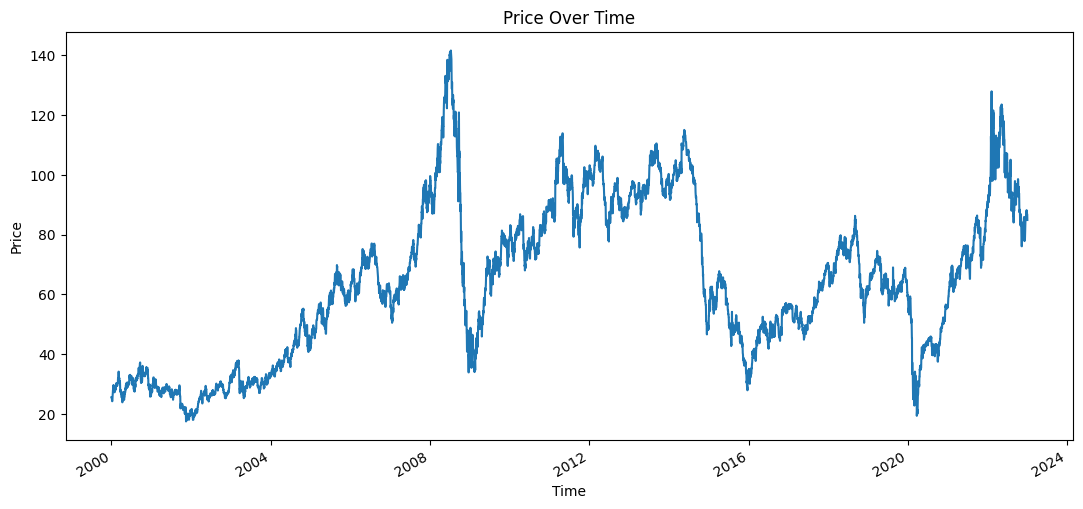

In [17]:
#plotting price over time-frame
data['PRICE'].plot(kind='line', figsize=(13, 6))
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price Over Time')
plt.show()

* **Denoise data**

/tmp/ipykernel_2055/803966981.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['PRICEG'] = gaussian_filter1d(data['PRICE'], sigma=sigma)


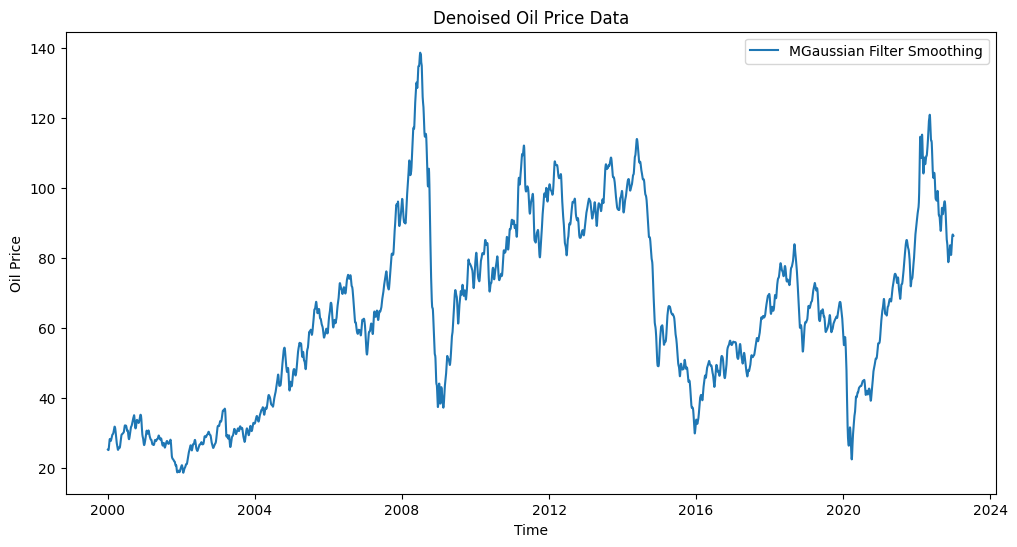

,USD/DZD,GPR,PRICE,PRICEG
DAY,,,,
2000-01-01,69.258,123.08,25.55,25.272929
2000-01-02,69.258,50.32,25.55,25.250758
2000-01-03,69.258,101.02,25.55,25.212659
2000-01-04,68.337,93.75,25.55,25.170451
2000-01-05,68.017,47.57,24.91,25.140147
...,...,...,...,...
2022-12-27,136.678,146.82,87.47,86.658100
2022-12-28,137.079,151.89,86.66,86.581204
2022-12-29,137.139,116.49,86.66,86.506870


In [18]:
# Smoothing using Gaussian Filter
sigma = 4
data['PRICEG'] = gaussian_filter1d(data['PRICE'], sigma=sigma)

# Plot the denoised data
plt.figure(figsize=(12, 6))
plt.plot(data['PRICEG'], label='MGaussian Filter Smoothing')
plt.title('Denoised Oil Price Data')
plt.xlabel('Time')
plt.ylabel('Oil Price')
plt.legend()
plt.show()
data

In [19]:
data['PRICE']=data['PRICEG']
data.drop('PRICEG', axis=1, inplace=True)
data

/tmp/ipykernel_2055/3899416492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['PRICE']=data['PRICEG']
/tmp/ipykernel_2055/3899416492.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('PRICEG', axis=1, inplace=True)


,USD/DZD,GPR,PRICE
DAY,,,
2000-01-01,69.258,123.08,25.272929
2000-01-02,69.258,50.32,25.250758
2000-01-03,69.258,101.02,25.212659
2000-01-04,68.337,93.75,25.170451
2000-01-05,68.017,47.57,25.140147
...,...,...,...
2022-12-27,136.678,146.82,86.658100
2022-12-28,137.079,151.89,86.581204
2022-12-29,137.139,116.49,86.506870


# **3- Discriptive Statistics**

## **3-1- Oil price fluctuations over the years**

In [20]:
yearly_avg = data['PRICE'].resample('Y').mean().reset_index()
yearly_avg['YEAR'] = yearly_avg['DAY'].dt.year

fig_yearly = px.line(
    yearly_avg,
    x='YEAR',
    y='PRICE',
    markers=True,
    title='Average Oil Price per Year'
)
fig_yearly.update_layout(xaxis_title='Year', yaxis_title='Average Oil Price')
fig_yearly.show()

/tmp/ipykernel_2055/2340763522.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = data['PRICE'].resample('Y').mean().reset_index()


## **3-2- Average Oil Price per Month - Seasonality**

In [21]:
monthly_avg = data.groupby(data.index.month)['PRICE'].mean().reset_index()
monthly_avg.columns = ['MONTH', 'PRICE']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['MONTH_NAME'] = monthly_avg['MONTH'].apply(lambda m: month_names[m - 1])

fig_monthly = px.bar(
    monthly_avg.sort_values('MONTH'),
    x='MONTH_NAME',
    y='PRICE',
    title='Average Oil Price by Month (all years combined)',
    text_auto='.2f'
)
fig_monthly.update_layout(xaxis_title='Month', yaxis_title='Average Oil Price')
fig_monthly.show()

## **3-3- GPR index vs Oil price**

In [22]:
# Daily view - dual axis
fig_gpr_daily = make_subplots(specs=[[{"secondary_y": True}]])

fig_gpr_daily.add_trace(
    go.Scatter(x=data.index, y=data['PRICE'], name='Oil Price', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig_gpr_daily.add_trace(
    go.Scatter(x=data.index, y=data['GPR'], name='GPR Index', line=dict(color='#d62728')),
    secondary_y=True
)

fig_gpr_daily.update_layout(title='Oil Price vs GPR Index Over Time')
fig_gpr_daily.update_yaxes(title_text='Oil Price', secondary_y=False)
fig_gpr_daily.update_yaxes(title_text='GPR Index', secondary_y=True)
fig_gpr_daily.show()

In [23]:
# Yearly average view - combo chart, easier to spot the relationship
yearly_gpr = data.resample('Y').mean().reset_index()
yearly_gpr['YEAR'] = yearly_gpr['DAY'].dt.year

fig_gpr_yearly = make_subplots(specs=[[{"secondary_y": True}]])

fig_gpr_yearly.add_trace(
    go.Bar(x=yearly_gpr['YEAR'], y=yearly_gpr['PRICE'], name='Avg Oil Price', marker_color='#1f77b4'),
    secondary_y=False
)
fig_gpr_yearly.add_trace(
    go.Scatter(x=yearly_gpr['YEAR'], y=yearly_gpr['GPR'], name='Avg GPR Index',
               line=dict(color='#d62728', width=3), mode='lines+markers'),
    secondary_y=True
)

fig_gpr_yearly.update_layout(title='Average Oil Price vs Average GPR Index per Year')
fig_gpr_yearly.update_yaxes(title_text='Avg Oil Price', secondary_y=False)
fig_gpr_yearly.update_yaxes(title_text='Avg GPR Index', secondary_y=True)
fig_gpr_yearly.show()

/tmp/ipykernel_2055/2106963385.py:2: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



## **3-4- USD/DZD exchange rate vs Oil price**

In [24]:
# Daily view - dual axis
fig_fx_daily = make_subplots(specs=[[{"secondary_y": True}]])

fig_fx_daily.add_trace(
    go.Scatter(x=data.index, y=data['PRICE'], name='Oil Price', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig_fx_daily.add_trace(
    go.Scatter(x=data.index, y=data['USD/DZD'], name='USD/DZD', line=dict(color='#2ca02c')),
    secondary_y=True
)

fig_fx_daily.update_layout(title='Oil Price vs USD/DZD Exchange Rate Over Time')
fig_fx_daily.update_yaxes(title_text='Oil Price', secondary_y=False)
fig_fx_daily.update_yaxes(title_text='USD/DZD', secondary_y=True)
fig_fx_daily.show()

In [25]:
# Yearly average view
fig_fx_yearly = make_subplots(specs=[[{"secondary_y": True}]])

fig_fx_yearly.add_trace(
    go.Bar(x=yearly_gpr['YEAR'], y=yearly_gpr['PRICE'], name='Avg Oil Price', marker_color='#1f77b4'),
    secondary_y=False
)
fig_fx_yearly.add_trace(
    go.Scatter(x=yearly_gpr['YEAR'], y=yearly_gpr['USD/DZD'], name='Avg USD/DZD',
               line=dict(color='#2ca02c', width=3), mode='lines+markers'),
    secondary_y=True
)

fig_fx_yearly.update_layout(title='Average Oil Price vs Average USD/DZD per Year')
fig_fx_yearly.update_yaxes(title_text='Avg Oil Price', secondary_y=False)
fig_fx_yearly.update_yaxes(title_text='Avg USD/DZD', secondary_y=True)
fig_fx_yearly.show()

## **3-5- Correlation heatmap**

# **4- Modeling**

## **4-1- Data spliting (train / validation / test)**

In [26]:
X = data.drop('PRICE', axis=1)
y = data['PRICE']

In [27]:
# hold out the final test set (untouched until final evaluation)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# carve a validation set out of the remaining training data
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)} | Validation size: {len(X_val)} | Test size: {len(X_test)}")

Train size: 5370 | Validation size: 1343 | Test size: 1679


## **4-2- Training**

### **I- Stand-alone models**

#### **4-2-1-1- SVR model**

In [28]:
# Define the parameter grid
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

svr=SVR()

In [29]:
# Perform grid search with MSE as the scoring metric
grid_search_svr = GridSearchCV(svr, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search_svr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             scoring='neg_mean_squared_error')

In [30]:
# Get the best parameters and the corresponding model
best_params_svr = grid_search_svr.best_params_
best_model_svr = grid_search_svr.best_estimator_

# Print best parameters and best score
print("Best Parameters found: ", grid_search_svr.best_params_)
print("Lowest score found: ", -grid_search_svr.best_score_)

Best Parameters found:  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Lowest score found:  463.77281996453684


In [31]:
# Evaluate on the validation set before touching the test set
svr_val_predictions = best_model_svr.predict(X_val)
svr_val_rmse = np.sqrt(mean_squared_error(y_val, svr_val_predictions))
svr_val_r2 = r2_score(y_val, svr_val_predictions)
print(f"Validation RMSE: {svr_val_rmse:.2f}")
print(f"Validation R2: {svr_val_r2:.2f}")

Validation RMSE: 22.63
Validation R2: 0.23


In [32]:
# Make predictions using the best model on the test set
svr_predictions = best_model_svr.predict(X_test)
svr_results = pd.DataFrame({'actual prices': y_test, 'svr predictionds': svr_predictions})
print(svr_results)

            actual prices  svr predictionds
DAY                                        
2008-04-11     110.493356        108.028773
2014-06-15     107.373151         98.015466
2005-07-24      58.773857         72.602048
2007-11-25      95.159061         92.364204
2006-02-24      61.529147         73.172172
...                   ...               ...
2019-04-16      71.404821         63.626804
2018-05-10      76.089681         62.300784
2000-11-20      35.238472         54.272712
2003-04-30      26.063182         28.507559
2018-04-08      76.025655         66.867111

[1679 rows x 2 columns]


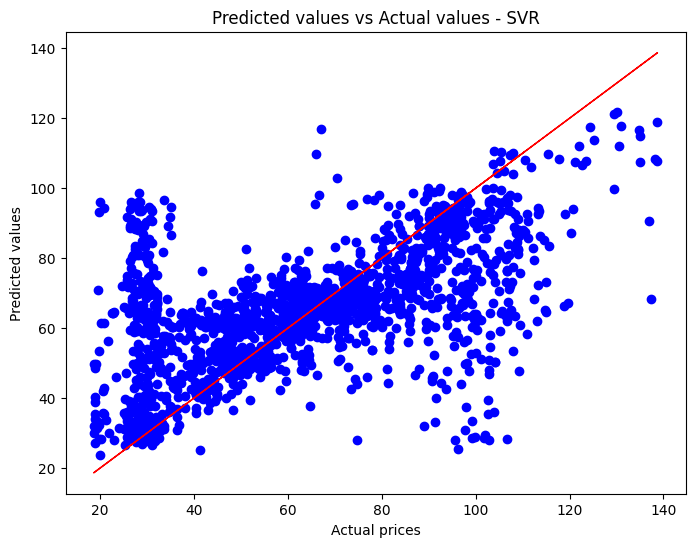

In [33]:
#Visualiaze predicted values vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual prices')
plt.ylabel('Predicted values')
plt.title('Predicted values vs Actual values - SVR')
plt.show()

In [34]:
# Calculate RMSE and R2
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_r2 = r2_score(y_test, svr_predictions)
print(f"RMSE: {svr_rmse:.2f}")
print(f"R2: {svr_r2:.2f}")

RMSE: 21.81
R2: 0.32


#### **4-2-1-2- Random Forest model**

In [35]:
seed=42
rf = RandomForestRegressor(random_state=seed)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
rf_val_predictions = rf.predict(X_val)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_predictions))
rf_val_r2 = r2_score(y_val, rf_val_predictions)
print(f"Validation RMSE: {rf_val_rmse:.2f}")
print(f"Validation R2: {rf_val_r2:.2f}")

Validation RMSE: 19.44
Validation R2: 0.43


In [37]:
rf_predictions = rf.predict(X_test)

In [38]:
resultsRF = pd.DataFrame({'actual prices': y_test, 'randomforest predictionds': rf_predictions})
print(resultsRF)

            actual prices  randomforest predictionds
DAY                                                 
2008-04-11     110.493356                 105.342669
2014-06-15     107.373151                  85.433570
2005-07-24      58.773857                  68.445362
2007-11-25      95.159061                  92.530036
2006-02-24      61.529147                  62.356526
...                   ...                        ...
2019-04-16      71.404821                  67.527213
2018-05-10      76.089681                  74.361087
2000-11-20      35.238472                  37.686091
2003-04-30      26.063182                  40.504664
2018-04-08      76.025655                  74.690025

[1679 rows x 2 columns]


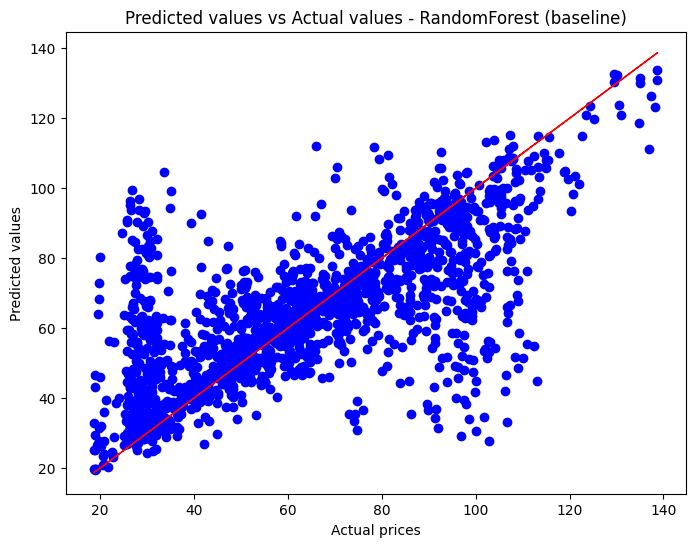

In [39]:
#visualize
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual prices')
plt.ylabel('Predicted values')
plt.title('Predicted values vs Actual values - RandomForest (baseline)')
plt.show()

In [40]:
rf_mse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Root Mean Squared Error: {rf_mse}")
rf_r2 = r2_score(y_test, rf_predictions)
print(f"R² = {rf_r2:.2f}")

Root Mean Squared Error: 19.049611027885426
R² = 0.48


#### **4-2-1-3- Random Forest (Grid Search tuning)**

In [41]:
# Define the parameter grid for the Random Forest model
param_grid = {
    'n_estimators': [10, 50, 100, 200, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [1, 2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize the Random Forest model
rf = RandomForestRegressor()

In [42]:
# Perform grid search to find the best parameters
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


500 fits failed out of a total of 2000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ut

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [1, 2, 5, 10],
                         'n_estimators': [10, 50, 100, 200, 500]},
             scoring='neg_mean_squared_error')

In [43]:
# Get the best model and its parameters
best_model_rf = grid_search.best_estimator_
best_params_rf = grid_search.best_params_

# Print best parameters and best score
print("Best Parameters found: ", grid_search.best_params_)
print("Lowest score found: ", -grid_search.best_score_)

Best Parameters found:  {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 500}
Lowest score found:  323.9632667556274


In [44]:
# Evaluate the tuned model on the validation set
rf_tuned_val_predictions = best_model_rf.predict(X_val)
rf_tuned_val_mse = mean_squared_error(y_val, rf_tuned_val_predictions)
rf_tuned_val_rmse = np.sqrt(rf_tuned_val_mse)
rf_tuned_val_r2 = r2_score(y_val, rf_tuned_val_predictions)
print(f"Validation RMSE: {rf_tuned_val_rmse:.2f}")
print(f"Validation R2: {rf_tuned_val_r2:.2f}")

Validation RMSE: 18.99
Validation R2: 0.46


In [45]:
# Use the best model to make predictions on the test set
rf_predictions = best_model_rf.predict(X_test)
resultsRF = pd.DataFrame({'actual prices': y_test, 'randomforest predictionds': rf_predictions})
print(resultsRF)

            actual prices  randomforest predictionds
DAY                                                 
2008-04-11     110.493356                 107.497484
2014-06-15     107.373151                  86.821836
2005-07-24      58.773857                  67.167681
2007-11-25      95.159061                  92.885967
2006-02-24      61.529147                  65.849144
...                   ...                        ...
2019-04-16      71.404821                  63.487304
2018-05-10      76.089681                  72.863787
2000-11-20      35.238472                  46.785288
2003-04-30      26.063182                  47.631659
2018-04-08      76.025655                  74.583479

[1679 rows x 2 columns]


In [46]:
# Calculate the Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
print(f'MSE: {rf_mse:.2f}')
# Calculate the Root Mean Squared Error (RMSE)
rf_rmse = rf_mse ** 0.5
print(f'RMSE: {rf_rmse:.2f}')
# Calculate the R-squared (R2)
rf_r2 = r2_score(y_test, rf_predictions)
print(f'R2: {rf_r2:.2f}')

MSE: 342.86
RMSE: 18.52
R2: 0.51


#### **4-2-1-4- XGBoost model**

In [47]:
# Define the parameter grid
param_grid = {
    'nthread': [4],
    'objective': ['reg:linear'],
    'learning_rate': [.03, 0.05, .07],
    'max_depth': [5, 6, 7],
    'min_child_weight': [3, 4],
    'silent': [1],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'n_estimators': [500]
}

# Initialize XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, eval_metric='rmse')

In [48]:
# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
# Fit GridSearchCV
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[20:53:16] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[20:53:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "silent" } are not used.




GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric='rmse',
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7],
                         'learning_rate': [0.03, 0.05, 0.07],
                         'max_depth': [5, 6, 7], 'min_child_weight': [3, 4],
                         'n_estimators': [500], 'nthread': [4],
                         'objective': ['reg:linear'], 'silent': [1],
                         'subsample': [0.7]},
             scoring='neg_mean_squared_error', verbose=2)

In [49]:
best_params_xgb = grid_search_xgb.best_params_
best_model_xgb = grid_search_xgb.best_estimator_

# Print best parameters and best score
print("Best Parameters found: ", grid_search_xgb.best_params_)
print("Lowest score found: ", -grid_search_xgb.best_score_)

Best Parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 500, 'nthread': 4, 'objective': 'reg:linear', 'silent': 1, 'subsample': 0.7}
Lowest score found:  371.31367313764633


In [50]:
# Evaluate on the validation set
xgb_val_predictions = best_model_xgb.predict(X_val)
xgb_val_mse = mean_squared_error(y_val, xgb_val_predictions)
xgb_val_rmse = np.sqrt(xgb_val_mse)
xgb_val_r2 = r2_score(y_val, xgb_val_predictions)
print(f"Validation RMSE: {xgb_val_rmse:.2f}")
print(f"Validation R2: {xgb_val_r2:.2f}")

Validation RMSE: 19.74
Validation R2: 0.42


In [51]:
# Use the best estimator to predict on test data
xgb_predictions = best_model_xgb.predict(X_test)
resultsXGB = pd.DataFrame({'actual prices': y_test, 'XGBoost predictionds': xgb_predictions})
print(resultsXGB)

            actual prices  XGBoost predictionds
DAY                                            
2008-04-11     110.493356            108.579887
2014-06-15     107.373151             66.883011
2005-07-24      58.773857             68.472092
2007-11-25      95.159061             90.921051
2006-02-24      61.529147             64.951744
...                   ...                   ...
2019-04-16      71.404821             65.099068
2018-05-10      76.089681             59.827381
2000-11-20      35.238472             48.647270
2003-04-30      26.063182             65.549583
2018-04-08      76.025655             77.462395

[1679 rows x 2 columns]


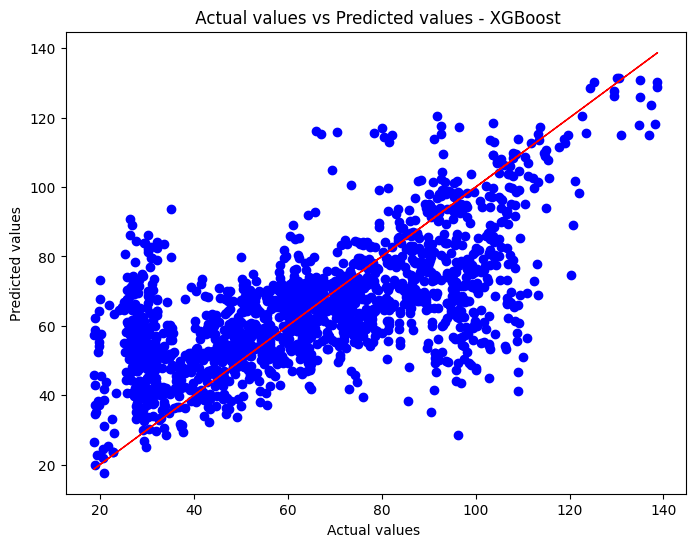

In [52]:
#visualize
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values ')
plt.ylabel('Predicted values')
plt.title(' Actual values vs Predicted values - XGBoost')
plt.show()

In [53]:
import numpy as np
# Calculate RMSE on test set
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
print(f"RMSE on test set: {xgb_rmse}")
xgb_r2 = r2_score(y_test, xgb_predictions)
print(f"R² = {xgb_r2:.2f}")

RMSE on test set: 19.819971038435618
R² = 0.44


#### **4-2-1-5- LSTM**

In [54]:
tf.random.set_seed(42)

In [55]:
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

In [56]:
sequence_length = 30  # Using 30 days of data to predict the next day's price
X, y = create_sequences(data['PRICE'], sequence_length)

/tmp/ipykernel_2055/2493092797.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [57]:
# Chronological 3-way split: train / validation / test (order preserved for time series)
split_train = int(0.8 * len(X))
split_val = int(0.9 * len(X))

X_train, X_val, X_test = X[:split_train], X[split_train:split_val], X[split_val:]
y_train, y_val, y_test = y[:split_train], y[split_train:split_val], y[split_val:]

In [58]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [59]:
lstm = Sequential()
lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm.add(LSTM(50))
lstm.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [60]:
lstm.compile(optimizer='adam', loss='mean_squared_error')

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 3689.8560 - val_loss: 2038.7499
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2559.6497 - val_loss: 1376.1736
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1951.4507 - val_loss: 936.9448
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1527.2637 - val_loss: 638.2587
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1230.8356 - val_loss: 441.8438
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1029.4371 - val_loss: 320.2492
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 898.6121 - val_loss: 251.7523
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 817.5763 - val_loss: 217.9482
Epoch 9/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 770.6075 - val_loss: 205.6341
Epoch 10/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 745.3466 - val_loss: 204.4848
Epoch 11/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 732.7614 - val_loss

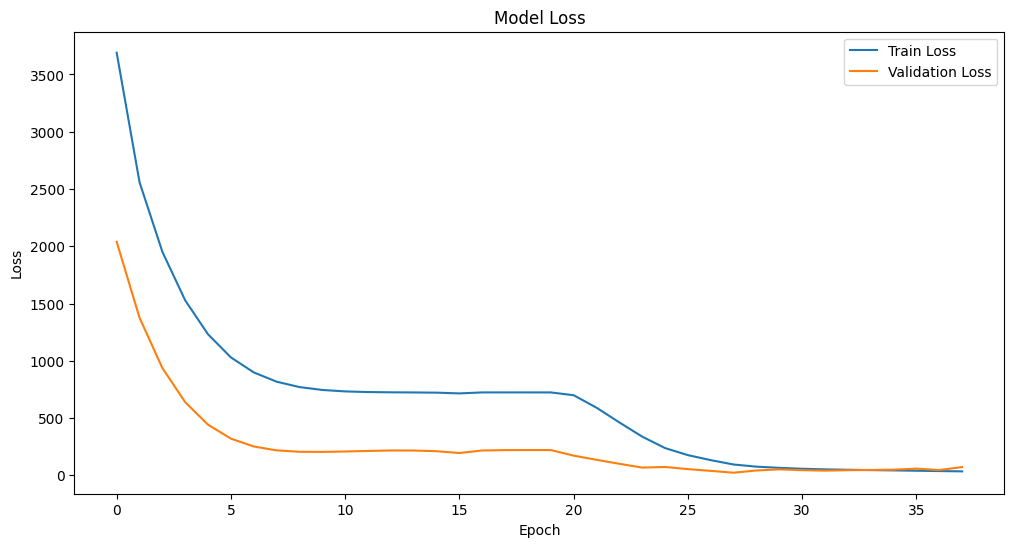

In [61]:
early_stop = EarlyStopping(monitor='val_loss', patience=10)

# Train the model - validation set used here, test set stays untouched
history = lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stop])

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [62]:
lstm_predictions = lstm.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [63]:
resultsLSTM = pd.DataFrame({'actual prices': y_test, 'lstm_predictions': lstm_predictions.flatten()})
print(resultsLSTM)

     actual prices  lstm_predictions
0        42.702582         37.582005
1        42.655013         37.610683
2        42.573336         37.511421
3        42.454084         37.312775
4        42.294030         37.041336
..             ...               ...
832      86.658100         83.941406
833      86.581204         82.414818
834      86.506870         80.747658
835      86.448682         79.139359
836      86.416841         77.790527

[837 rows x 2 columns]


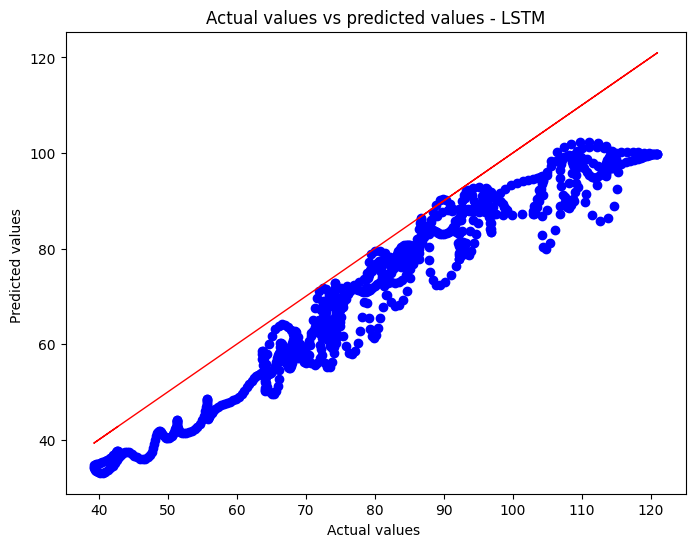

In [64]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lstm_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values ')
plt.ylabel('Predicted values ')
plt.title('Actual values vs predicted values - LSTM')
plt.show()

In [65]:
# Calculate RMSE on test set
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
print(f"RMSE on test set: {lstm_rmse}")
lstm_r2 = r2_score(y_test, lstm_predictions)
print(f"R² = {lstm_r2:.2f}")

RMSE on test set: 10.405409188213921
R² = 0.72


#### **4-2-1-6- CNN**

In [66]:
X = X.reshape(X.shape[0], X.shape[1], 1)

# Step 1: hold out test set
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Step 2: carve validation set out of training data
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [67]:
cnn = Sequential()
cnn.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
cnn.add(MaxPooling1D(pool_size=2))
cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn.add(MaxPooling1D(pool_size=2))
cnn.add(Flatten())
cnn.add(Dense(units=128, activation='relu'))
cnn.add(Dropout(rate=0.5))
cnn.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [68]:
cnn.compile(optimizer='adam', loss='mean_squared_error')

In [69]:
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')

cnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 313.7667 - val_loss: 13.8569
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 156.5234 - val_loss: 12.7994
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 160.4296 - val_loss: 17.1903
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 151.9875 - val_loss: 21.2045
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 152.8553 - val_loss: 15.8800
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 147.7263 - val_loss: 13.4040
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 146.7736 - val_loss: 8.4484
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 150.0475 - val_loss: 10.4417
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 150.8980 - val_loss: 14.7162
Epoch 10/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 145.0267 - val_loss: 7.5163
Epoch 11/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 136.8814 - val_loss: 9.0629
Epoch 12/50
168/168 ━━

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.0254
Test loss: 28.02544403076172


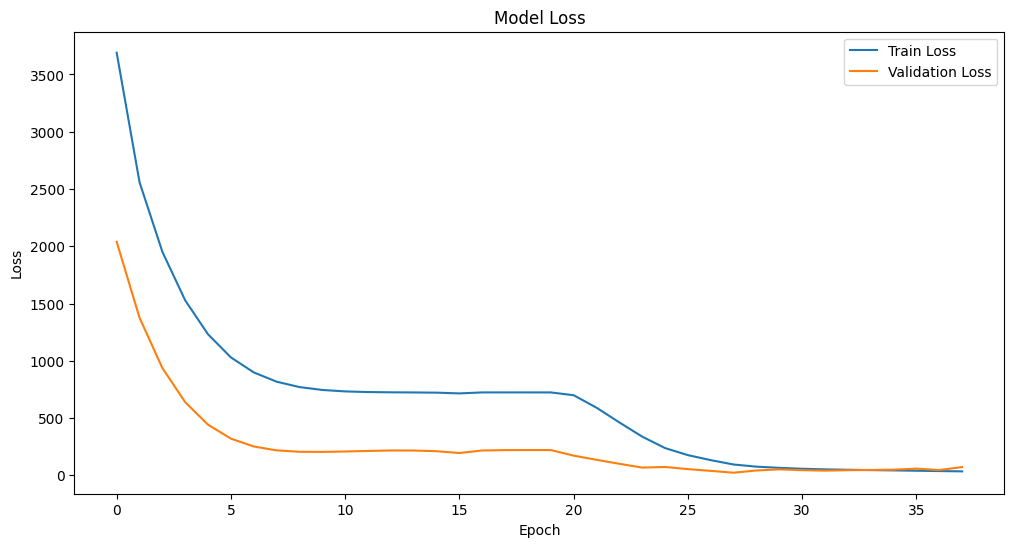

In [70]:
loss = cnn.evaluate(X_test, y_test)
print('Test loss:', loss)
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [71]:
cnn_predictions = cnn.predict(X_test)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [72]:
resultsCNN = pd.DataFrame({'actual prices': y_test, 'cnn_predictions': cnn_predictions.flatten()})
print(resultsCNN)

      actual prices  cnn_predictions
0         94.699287        95.614510
1         65.138100        63.746189
2         38.852539        39.416058
3         46.560364        44.494560
4         64.242432        64.017311
...             ...              ...
1668      91.275772        85.199631
1669      88.688652        83.224815
1670     112.065720       105.836571
1671      18.977600        18.507318
1672      46.964287        44.855927

[1673 rows x 2 columns]


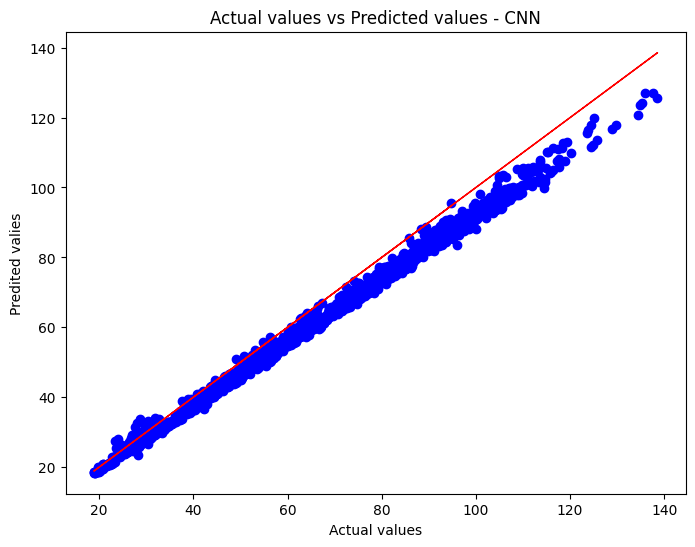

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, cnn_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values')
plt.ylabel('Predited valies')
plt.title('Actual values vs Predicted values - CNN')
plt.show()

In [74]:
# Calculate RMSE on test set
cnn_mse = mean_squared_error(y_test, cnn_predictions)
cnn_rmse = np.sqrt(cnn_mse)
print(f"RMSE on test set: {cnn_rmse}")
cnn_r2 = r2_score(y_test, cnn_predictions)
print(f"R² = {cnn_r2:.2f}")

RMSE on test set: 5.293906491251083
R² = 0.96


### **II- Hybrid models**

#### **4-2-2-1- CNN-LSTM**

In [75]:
Oil_price = data['PRICE'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(Oil_price)

In [76]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(scaled_prices, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Step 1: hold out test set
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Step 2: carve validation set out of training data
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [77]:
# Define the LSTM-CNN hybrid model
input_layer = Input(shape=(time_step, 1))

# CNN part
conv1 = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
maxpool1 = MaxPooling1D(pool_size=2)(conv1)
flatten = Flatten()(maxpool1)

# LSTM part
lstm = LSTM(50, return_sequences=True)(input_layer)
lstm = LSTM(50)(lstm)

# Concatenate CNN and LSTM parts
concat = Concatenate()([flatten, lstm])

# Fully connected layers
dense1 = Dense(50, activation='relu')(concat)
output = Dense(1)(dense1)

# Create the model
cnn_lstm = Model(inputs=input_layer, outputs=output)

# Compile the model
cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model
cnn_lstm.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 9, 64)     │        192 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 4, 64)     │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 50)    │     10,400 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 256)       │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 50)        │     20,200 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 306)       │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50)        │     15,350 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         51 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,193 (180.44 KB)

 Trainable params: 46,193 (180.44 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Train the model - use validation set, test set stays held out
history = cnn_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0052 - val_loss: 2.1510e-04
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.6207e-04 - val_loss: 2.0313e-04
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.4962e-04 - val_loss: 1.6467e-04
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3713e-04 - val_loss: 1.6246e-04
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.2050e-04 - val_loss: 1.3587e-04
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.0641e-04 - val_loss: 1.1925e-04
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 9.5195e-05 - val_loss: 1.2917e-04
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 8.4229e-05 - val_loss: 1.4639e-04
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.9657e-05 - val_loss: 7.2269e-05
Epoch 10/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.1421e-05 - val_loss: 6.1866e-05
Epoch 11/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

In [79]:
# Evaluate the model
train_loss = cnn_lstm.evaluate(X_train, y_train, verbose=0)
val_loss = cnn_lstm.evaluate(X_val, y_val, verbose=0)
test_loss = cnn_lstm.evaluate(X_test, y_test, verbose=0)
print(f'Train Loss: {train_loss}, Validation Loss: {val_loss}, Test Loss: {test_loss}')

Train Loss: 2.2279180484474637e-05, Validation Loss: 2.4110127924359404e-05, Test Loss: 2.187437166867312e-05


In [80]:
# Make predictions
cnn_lstm_predictions = cnn_lstm.predict(X_test)

# Inverse transform the predictions to get the actual prices
cnn_lstm_predictions = scaler.inverse_transform(cnn_lstm_predictions)

y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [81]:
# Ensure y_test and cnn_lstm_predictions are numpy arrays
y_test = np.array(y_test)
cnn_lstm_predictions = np.array(cnn_lstm_predictions)

# Check the shape of y_test and cnn_lstm_predictions
print("Shape of y_test:", y_test.shape)
print("Shape of cnn_lstm_predictions:", cnn_lstm_predictions.shape)

Shape of y_test: (1677, 1)
Shape of cnn_lstm_predictions: (1677, 1)


In [82]:
if y_test.ndim > 1:
    y_test = y_test.reshape(-1)

if cnn_lstm_predictions.ndim > 1:
    cnn_lstm_predictions = cnn_lstm_predictions.reshape(-1)

In [83]:
resultsCNNlstm = pd.DataFrame({'actual prices': y_test, 'cnn lstm predictions': cnn_lstm_predictions})
print(resultsCNNlstm)

      actual prices  cnn lstm predictions
0         94.962974             95.191605
1        107.981214            109.719078
2         48.530286             48.954655
3         95.626969             96.345787
4         60.090281             60.021175
...             ...                   ...
1672      35.962855             36.113640
1673      61.824139             62.768944
1674      52.135276             52.449047
1675      49.358847             49.806492
1676     115.551182            116.303497

[1677 rows x 2 columns]


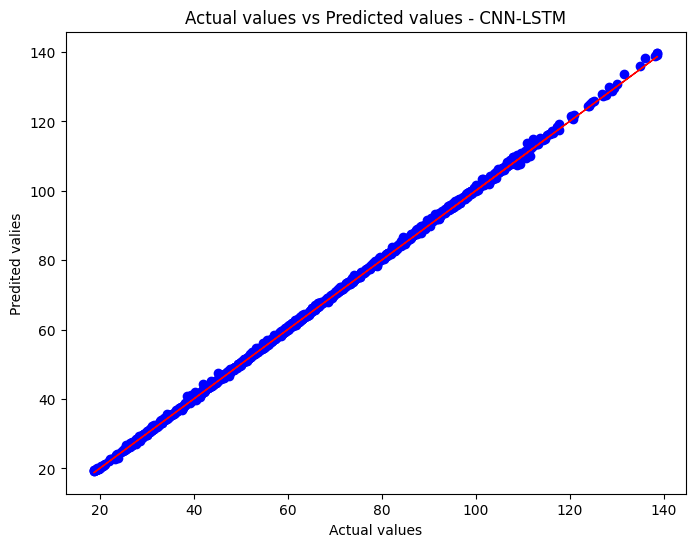

In [84]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, cnn_lstm_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values')
plt.ylabel('Predited valies')
plt.title('Actual values vs Predicted values - CNN-LSTM')
plt.show()

In [85]:
# Calculate RMSE on test set
cnn_lstm_mse = mean_squared_error(y_test, cnn_lstm_predictions)
cnn_lstm_rmse = np.sqrt(cnn_lstm_mse)
print(f"RMSE on test set: {cnn_lstm_rmse}")
cnn_lstm_r2 = r2_score(y_test, cnn_lstm_predictions)
print(f"R² = {cnn_lstm_r2:.2f}")

RMSE on test set: 0.5614623966549258
R² = 1.00


#### **4-2-2-2- RandomForest-XGBoost**

In [86]:
# Flatten the 3D sequence arrays (from the LSTM-CNN section) into 2D for RF/XGB
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train individual models
rf = RandomForestRegressor()
rf.fit(X_train_flat, y_train)

xgb = XGBRegressor()
xgb.fit(X_train_flat, y_train)

# Combine predictions from individual models
X_train_hybrid = np.column_stack((rf.predict(X_train_flat), xgb.predict(X_train_flat)))
X_val_hybrid = np.column_stack((rf.predict(X_val_flat), xgb.predict(X_val_flat)))
X_test_hybrid = np.column_stack((rf.predict(X_test_flat), xgb.predict(X_test_flat)))

# Train hybrid model using Linear Regression
rf_xgb = LinearRegression()
rf_xgb.fit(X_train_hybrid, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



LinearRegression()

In [87]:
# Evaluate hybrid model on the validation set
rf_xgb_val_predictions = rf_xgb.predict(X_val_hybrid)
rf_xgb_val_mse = mean_squared_error(y_val, rf_xgb_val_predictions)
rf_xgb_val_rmse = np.sqrt(rf_xgb_val_mse)
rf_xgb_val_r2 = r2_score(y_val, rf_xgb_val_predictions)
print(f"Validation RMSE: {rf_xgb_val_rmse:.2f}")
print(f"Validation R2: {rf_xgb_val_r2:.2f}")

Validation RMSE: 0.23
Validation R2: 1.00


In [88]:
# Evaluate hybrid model on test set
rf_xgb_predictions = rf_xgb.predict(X_test_hybrid)
resultsrf_xgb = pd.DataFrame({'actual prices': y_test, 'rf_xgb_predictions': rf_xgb_predictions.flatten()})
print(resultsrf_xgb)

      actual prices  rf_xgb_predictions
0         94.962974           94.907877
1        107.981214          108.108158
2         48.530286           48.460860
3         95.626969           95.686476
4         60.090281           59.867575
...             ...                 ...
1672      35.962855           35.882845
1673      61.824139           61.996173
1674      52.135276           52.116327
1675      49.358847           49.559382
1676     115.551182          115.290390

[1677 rows x 2 columns]


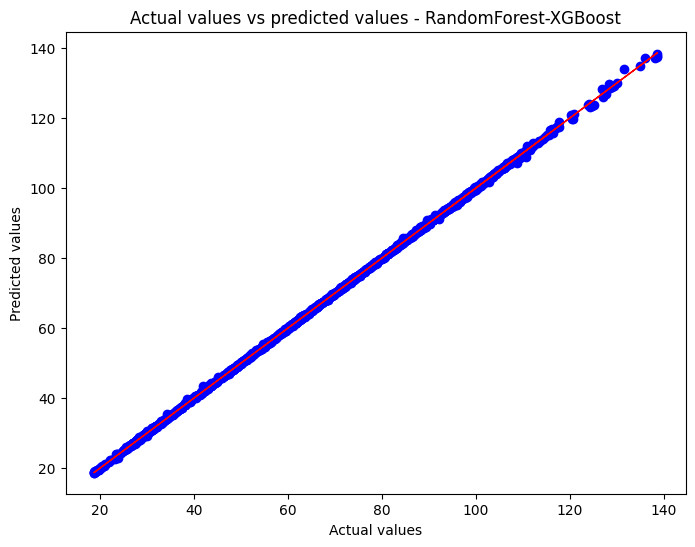

In [89]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_xgb_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual values vs predicted values - RandomForest-XGBoost')
plt.show()

In [90]:
# Calculate RMSE and R2 (English labels)
rf_xgb_rmse = np.sqrt(mean_squared_error(y_test, rf_xgb_predictions))
rf_xgb_r2 = r2_score(y_test, rf_xgb_predictions)
print(f"RMSE: {rf_xgb_rmse:.2f}")
print(f"R2: {rf_xgb_r2:.2f}")

RMSE: 0.24
R2: 1.00


# **COMPARISON**

/tmp/ipykernel_2055/2493092797.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



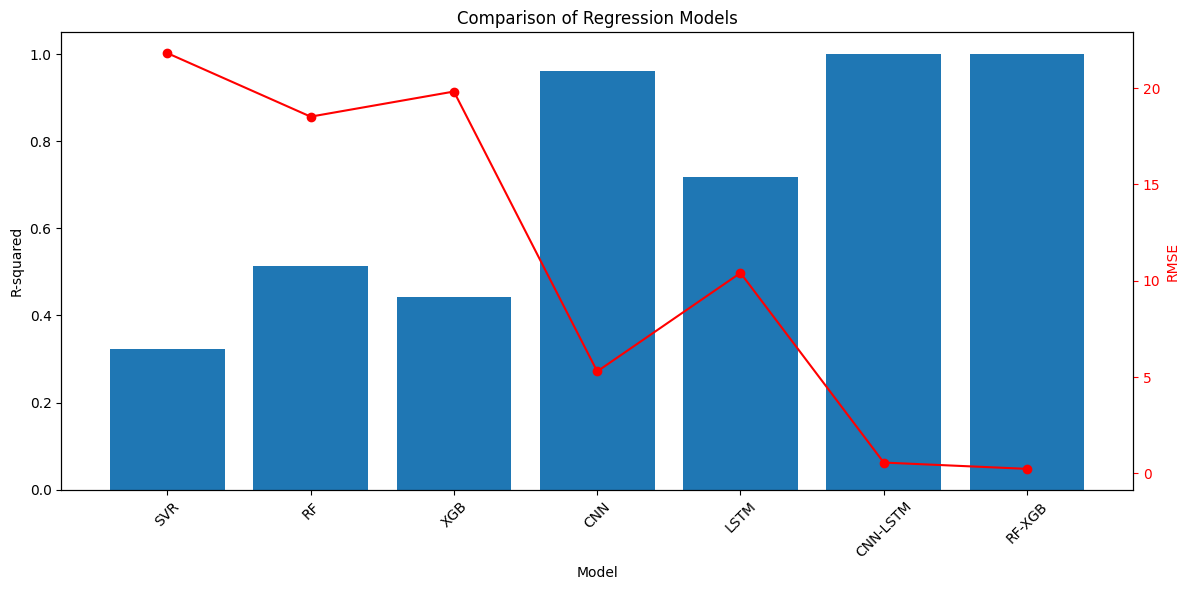

In [91]:
# Create a list of your predictions
predictions_list = [svr_predictions, rf_predictions, xgb_predictions, cnn_predictions, lstm_predictions, cnn_lstm_predictions, rf_xgb_predictions]

# Create a list of model names or labels
model_names = ['SVR', 'RF', 'XGB', 'CNN', 'LSTM', 'CNN-LSTM', 'RF-XGB']

# --- Recreate/Identify correct y_test for each model ---

# 1. For SVR, RF, XGBoost (original split before time series processing)
X_initial = data.drop('PRICE', axis=1)
y_initial = data['PRICE']
_, _, _, y_test_traditional = train_test_split(X_initial, y_initial, test_size=0.2, random_state=42)

# 2. For LSTM (chronological split)
sequence_length_lstm = 30
X_lstm_base, y_lstm_base = create_sequences(data['PRICE'], sequence_length_lstm)
split_train_lstm = int(0.8 * len(X_lstm_base))
split_val_lstm = int(0.9 * len(X_lstm_base))
# The y_test for LSTM was derived from y_lstm_base[split_val_lstm:]
y_test_lstm_specific = y_lstm_base[split_val_lstm:]

# 3. For CNN (split after sequence creation + reshape)
# X_cnn_base is the X_lstm_base reshaped
X_cnn_base = X_lstm_base.reshape(X_lstm_base.shape[0], X_lstm_base.shape[1], 1)
y_cnn_base = y_lstm_base # y_cnn_base is the same as y_lstm_base
_, _, _, y_test_cnn_specific = train_test_split(X_cnn_base, y_cnn_base, test_size=0.2, random_state=42)
# The y_test_cnn_specific was cast to float32 for CNN training, so ensure consistency
y_test_cnn_specific = y_test_cnn_specific.astype('float32')

# 4. For CNN-LSTM and RF-XGBoost (current global y_test, which is already inverse-transformed and has 1677 samples)
y_test_cnn_lstm_specific = y_test # Using the current global y_test

# Compile the list of y_true arrays in the correct order corresponding to predictions_list
y_true_for_comparison = [
    y_test_traditional, # SVR
    y_test_traditional, # RF
    y_test_traditional, # XGB
    y_test_cnn_specific, # CNN
    y_test_lstm_specific, # LSTM
    y_test_cnn_lstm_specific, # CNN-LSTM
    y_test_cnn_lstm_specific  # RF-XGB
]

# Ensure prediction arrays are flat and y_true are aligned for comparison
predictions_flat = []
for pred in predictions_list:
    if pred.ndim > 1:
        predictions_flat.append(pred.flatten())
    else:
        predictions_flat.append(pred)

y_true_for_comparison_flat = []
for y_t in y_true_for_comparison:
    if y_t.ndim > 1:
        y_true_for_comparison_flat.append(y_t.flatten())
    else:
        y_true_for_comparison_flat.append(y_t)

# Calculate the R-squared and RMSE values for each model
r_squared_values = [r2_score(y_true, y_pred) for y_true, y_pred in zip(y_true_for_comparison_flat, predictions_flat)]
rmse_values = [np.sqrt(mean_squared_error(y_true, y_pred)) for y_true, y_pred in zip(y_true_for_comparison_flat, predictions_flat)]

# Create the figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the R-squared values
ax1.bar(model_names, r_squared_values)
ax1.set_title('Comparison of Regression Models')
ax1.set_xlabel('Model')
ax1.set_ylabel('R-squared')
ax1.tick_params(axis='x', rotation=45)

# Create a twin axis for the RMSE values
ax2 = ax1.twinx()

# Plot the RMSE values
ax2.plot(model_names, rmse_values, marker='o', color='r')
ax2.set_ylabel('RMSE', color='r')
ax2.tick_params('y', colors='r')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()